In [32]:
import geopandas as gpd
import pandas as pd

import mapillary as mly
import json



### netzwerk einlesen

In [33]:
#highways=gpd.read_file("../preprocessing/processed_osm_files/processed_major_highways_germany_250528.geojson.gz")

# use not only the major highways, but all highways for this
#cycleways=gpd.read_file("../preprocessing/processed_osm_files/processed_cycleways_germany_250528.geojson.gz")


set_date = "250731" # 2025-07-31

cycleways=gpd.read_parquet(f"../preprocessing/processed_osm_files/processed_cycleways_germany_{set_date}.parquet")



In [34]:
len(cycleways)

7421066

In [35]:
cycleways.columns

Index(['osm_id', 'highway', 'bicycle', 'bicycle_forward', 'bicycle_backward',
       'cycleway', 'cycleway_left', 'cycleway_right', 'cycleway_both',
       'cycleway_lane', 'cycleway_track', 'cycleway_opposite',
       'cycleway_shared_lane', 'sidewalk_right_bicycle',
       'sidewalk_left_bicycle', 'sidewalk_both_bicycle', 'maxspeed',
       'maxspeed_conditional', 'maxspeed_backward', 'maxspeed_forward',
       'maxspeed_type', 'name', 'ref', 'surface', 'width', 'geometry'],
      dtype='object')

In [36]:
filtered_cycleways = cycleways[
    (cycleways["bicycle"].isin(["designated"])) |
    (cycleways["bicycle_backward"].isin(["designated"])) |
    (cycleways["bicycle_forward"].isin(["designated"])) |
    (cycleways["highway"].isin(["cycleway"])) |
    # (cycleways["cycleway"].notnull()) |
    # (cycleways["cycleway_left"].notnull()) |
    # (cycleways["cycleway_right"].notnull()) |
    # (cycleways["cycleway_both"].notnull()) |
    # (cycleways["cycleway_lane"].notnull()) |
    # (cycleways["cycleway_track"].notnull()) |
    (cycleways["cycleway"].notnull() & (cycleways["cycleway"] != "no")) |
    (cycleways["cycleway_left"].notnull() & (cycleways["cycleway_left"] != "no")) |
    (cycleways["cycleway_right"].notnull() & (cycleways["cycleway_right"] != "no")) |
    (cycleways["cycleway_both"].notnull() & (cycleways["cycleway_both"] != "no")) |
    (cycleways["cycleway_lane"].notnull() & (cycleways["cycleway_lane"] != "no")) |
    (cycleways["cycleway_track"].notnull() & (cycleways["cycleway_track"] != "no")) |
    # (cycleways["cycleway_opposite"].notnull()) 
    (cycleways["sidewalk_right_bicycle"].isin(["designated"])) |
    (cycleways["sidewalk_left_bicycle"].isin(["designated"])) |
    (cycleways["sidewalk_both_bicycle"].isin(["designated"])) 
]
filtered_cycleways

,osm_id,highway,bicycle,bicycle_forward,bicycle_backward,cycleway,cycleway_left,cycleway_right,cycleway_both,cycleway_lane,...,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name,ref,surface,width,geometry
29,2187,secondary,None,None,None,None,no,separate,None,None,...,None,None,None,70,None,Münchner Straße,St 2573,asphalt,None,"LINESTRING (11.66896 47.91703, 11.66916 47.916..."
107,1713370,primary,use_sidepath,None,None,separate,None,None,None,None,...,70,None,None,None,None,None,B 26;L 3303,asphalt,None,"LINESTRING (8.54788 49.85892, 8.54751 49.85889..."
134,1846729,tertiary,None,None,None,None,None,None,separate,None,...,50,None,None,None,None,Nobelstraße,None,asphalt,None,"LINESTRING (9.09343 48.739, 9.09368 48.73909, ..."
136,1846731,tertiary,None,None,None,None,separate,no,None,None,...,50,None,None,None,None,Universitätsstraße,None,asphalt,None,"LINESTRING (9.10376 48.74079, 9.10382 48.74087..."
160,1880870,residential,None,None,None,None,None,track,None,None,...,30,None,None,None,None,Altwiedenthaler Straße,None,asphalt,None,"LINESTRING (9.88829 53.47808, 9.88828 53.478, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7421046,1419005475,path,designated,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,paved,None,"LINESTRING (6.43019 51.17471, 6.43029 51.17472..."
7421058,1419006103,primary,use_sidepath,None,None,None,no,separate,None,None,...,None,None,None,None,None,Stadländer Straße,B 212,asphalt,None,"LINESTRING (8.45077 53.4712, 8.45073 53.47112)"
7421059,1419006104,primary,use_sidepath,None,None,None,no,separate,None,None,...,None,None,None,None,None,Stadländer Straße,B 212,asphalt,None,"LINESTRING (8.45073 53.47112, 8.4506 53.47089)"
7421060,1419006109,primary,use_sidepath,None,None,None,no,separate,None,None,...,50,None,None,None,sign,Stadländer Straße,B 212,asphalt,None,"LINESTRING (8.45206 53.47327, 8.45192 53.47306..."


In [37]:
filtered_cycleways.highway.value_counts()

highway
path                        305765
secondary                   111659
cycleway                     88860
tertiary                     77220
primary                      59764
residential                  41706
footway                      18661
unclassified                 11953
track                        11890
service                       7097
living_street                 1656
secondary_link                1588
primary_link                  1399
tertiary_link                  909
construction                   726
trunk                          610
pedestrian                     584
trunk_link                     526
steps                          292
proposed                        94
motorway_link                   58
platform                        49
planned                         11
road                            11
busway                          10
bridleway                        2
p<<                              1
bus_stop                         1
motorway    

In [7]:
# # mapillary map feature data: != traffic signs
# https://www.mapillary.com/developer/api-documentation/points?locale=de_DE

# mapillary_mapfeaturepoints = gpd.read_parquet("../preprocessing/mapillary_map-feature-points_data_bbb_2025-06-11.parquet")
# mapillary_mapfeaturepoints


# LANE MARKINGS!!!
# https://www.mapillary.com/developer/api-documentation/points?locale=de_DE
# mapillary_mapfeaturepoints_bclane=mapillary_mapfeaturepoints[mapillary_mapfeaturepoints.value=="marking--discrete--symbol--bicycle"]
# mapillary_mapfeaturepoints_bclane

In [ ]:

## TRAFFFIC SIGNS
# https://www.mapillary.com/developer/api-documentation/traffic-signs?locale=

# Unterschiedliche Verkehrszeichen in Deutschland für Radwege

# https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:237
de_237="regulatory--bicycles-only--g1"

# https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:240
de_240="regulatory--shared-path-pedestrians-and-bicycles--g1"

# https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:241-30
de_241_30="regulatory--dual-path-bicycles-and-pedestrians--g1"

# https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:241-31
de_241_31="regulatory--dual-path-pedestrians-and-bicycles--g1"


# ggf. noch  "complementary--except-bicycles--g1" https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:1022-10



#mapillary_trafficsigns = gpd.read_parquet("../preprocessing/mapillary_map-feature-data_ger_2025-06-07.parquet") ## -> 184120 features
mapillary_trafficsigns = gpd.read_parquet("../preprocessing/mapillary_map-feature-data_ger_2025-07-30.parquet") ## -> 213732 features


# Schilder in Germany
mapillary_trafficsigns_cw=mapillary_trafficsigns[mapillary_trafficsigns.value.isin([de_237, de_240, de_241_30, de_241_31])]
mapillary_trafficsigns_cw

,geometry,first_seen_at,id,last_seen_at,value
221,POINT (5.90829 51.01523),2016-07-30,301371998064492,2016-07-30,regulatory--bicycles-only--g1
228,POINT (5.90258 51.01893),2016-07-30,854188721831494,2016-07-30,regulatory--shared-path-pedestrians-and-bicycl...
281,POINT (5.90159 51.01922),2015-02-07,3249656101804613,2015-02-07,regulatory--shared-path-pedestrians-and-bicycl...
529,POINT (5.90813 51.01569),2016-11-19,4338004276257040,2016-11-19,regulatory--shared-path-pedestrians-and-bicycl...
604,POINT (5.89027 51.01019),2023-01-29,1235766320341501,2023-01-29,regulatory--bicycles-only--g1
...,...,...,...,...,...
6074496,POINT (15.00247 51.15051),2023-01-06,2172080486304870,2023-01-06,regulatory--dual-path-bicycles-and-pedestrians...
6074499,POINT (15.00622 51.14971),2020-01-11,525956591746576,2020-01-11,regulatory--bicycles-only--g1
6074541,POINT (15.0049 51.15125),2019-06-12,2886143721626841,2019-06-12,regulatory--shared-path-pedestrians-and-bicycl...
6074591,POINT (15.00406 51.15085),2024-04-19,345435275206045,2024-04-19,regulatory--shared-path-pedestrians-and-bicycl...


In [39]:
# mapillary_trafficsigns_237_recent = mapillary_trafficsigns_cw[mapillary_trafficsigns_cw["last_seen_at"] > "2024-01-01"]
# mapillary_trafficsigns_237_recent

In [42]:
from datetime import datetime

def months_between(date1, date2):
    d1 = datetime.strptime(date1, "%Y-%m-%d")
    d2 = datetime.strptime(date2, "%Y-%m-%d")
    return abs((d2.year - d1.year) * 12 + d2.month - d1.month)

mapillary_trafficsigns_cw_1year = mapillary_trafficsigns_cw[
    mapillary_trafficsigns_cw.apply(lambda row: months_between(row['first_seen_at'], row['last_seen_at']) >= 12, axis=1)
]
mapillary_trafficsigns_cw_1year

,geometry,first_seen_at,id,last_seen_at,value
2149,POINT (5.96425 51.8117),2020-05-23,184553600207023,2025-03-22,regulatory--shared-path-pedestrians-and-bicycl...
2221,POINT (5.96781 51.80977),2020-05-23,4324714694228518,2025-05-10,regulatory--shared-path-pedestrians-and-bicycl...
2254,POINT (5.96461 51.81197),2021-10-17,197492709187072,2024-12-08,regulatory--shared-path-pedestrians-and-bicycl...
2360,POINT (5.96456 51.81203),2017-03-24,2988469541382285,2024-07-16,regulatory--shared-path-pedestrians-and-bicycl...
3021,POINT (5.95883 50.80568),2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1
...,...,...,...,...,...
6072528,POINT (15.00693 51.14961),2020-02-24,476380323475589,2021-07-29,regulatory--dual-path-bicycles-and-pedestrians...
6072814,POINT (15.00439 51.15082),2019-05-23,739427700031617,2024-01-31,regulatory--shared-path-pedestrians-and-bicycl...
6072913,POINT (14.99091 51.15028),2021-06-28,1706665812854785,2022-06-22,regulatory--shared-path-pedestrians-and-bicycl...
6074443,POINT (14.9908 51.1509),2018-09-04,249372320311931,2022-07-28,regulatory--shared-path-pedestrians-and-bicycl...


<Axes: >

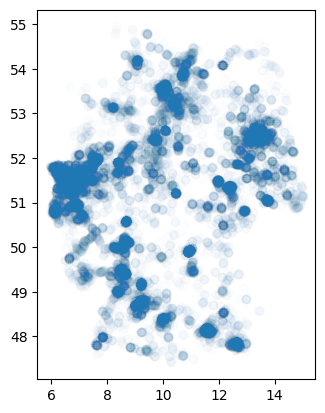

In [43]:
mapillary_trafficsigns_cw_1year.plot(alpha=0.01)

In [44]:
df_buffered = mapillary_trafficsigns_cw_1year.to_crs(25833).copy()
df_buffered["geometry"] = df_buffered.geometry.buffer(50)
df_buffered = df_buffered.to_crs(mapillary_trafficsigns_cw_1year.crs)
df_buffered

,geometry,first_seen_at,id,last_seen_at,value
2149,"POLYGON ((5.96496 51.81175, 5.96497 51.81171, ...",2020-05-23,184553600207023,2025-03-22,regulatory--shared-path-pedestrians-and-bicycl...
2221,"POLYGON ((5.96853 51.80982, 5.96853 51.80978, ...",2020-05-23,4324714694228518,2025-05-10,regulatory--shared-path-pedestrians-and-bicycl...
2254,"POLYGON ((5.96532 51.81203, 5.96533 51.81198, ...",2021-10-17,197492709187072,2024-12-08,regulatory--shared-path-pedestrians-and-bicycl...
2360,"POLYGON ((5.96527 51.81208, 5.96528 51.81204, ...",2017-03-24,2988469541382285,2024-07-16,regulatory--shared-path-pedestrians-and-bicycl...
3021,"POLYGON ((5.95953 50.80574, 5.95953 50.80569, ...",2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1
...,...,...,...,...,...
6072528,"POLYGON ((15.00765 51.14961, 15.00764 51.14956...",2020-02-24,476380323475589,2021-07-29,regulatory--dual-path-bicycles-and-pedestrians...
6072814,"POLYGON ((15.0051 51.15082, 15.0051 51.15078, ...",2019-05-23,739427700031617,2024-01-31,regulatory--shared-path-pedestrians-and-bicycl...
6072913,"POLYGON ((14.99163 51.15028, 14.99163 51.15024...",2021-06-28,1706665812854785,2022-06-22,regulatory--shared-path-pedestrians-and-bicycl...
6074443,"POLYGON ((14.99151 51.1509, 14.99151 51.15086,...",2018-09-04,249372320311931,2022-07-28,regulatory--shared-path-pedestrians-and-bicycl...


In [45]:
df_buffered=df_buffered[df_buffered["last_seen_at"] > "2025-01-01"]
df_buffered

,geometry,first_seen_at,id,last_seen_at,value
2149,"POLYGON ((5.96496 51.81175, 5.96497 51.81171, ...",2020-05-23,184553600207023,2025-03-22,regulatory--shared-path-pedestrians-and-bicycl...
2221,"POLYGON ((5.96853 51.80982, 5.96853 51.80978, ...",2020-05-23,4324714694228518,2025-05-10,regulatory--shared-path-pedestrians-and-bicycl...
3021,"POLYGON ((5.95953 50.80574, 5.95953 50.80569, ...",2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1
3163,"POLYGON ((5.95949 50.80578, 5.95949 50.80574, ...",2014-11-19,918053748737717,2025-05-09,regulatory--bicycles-only--g1
3328,"POLYGON ((5.97834 51.79875, 5.97834 51.7987, 5...",2019-11-16,3906871189403021,2025-05-10,regulatory--shared-path-pedestrians-and-bicycl...
...,...,...,...,...,...
6063016,"POLYGON ((14.84332 50.90382, 14.84332 50.90378...",2020-09-18,1881483988693301,2025-05-02,regulatory--shared-path-pedestrians-and-bicycl...
6066573,"POLYGON ((14.96421 51.35025, 14.96421 51.35021...",2020-09-18,182117573802701,2025-05-29,regulatory--dual-path-bicycles-and-pedestrians...
6066685,"POLYGON ((14.971 51.33449, 14.97099 51.33445, ...",2016-01-06,578409433667030,2025-05-29,regulatory--shared-path-pedestrians-and-bicycl...
6066978,"POLYGON ((14.97108 51.1668, 14.97108 51.16676,...",2018-06-01,501178517751828,2025-05-29,regulatory--dual-path-bicycles-and-pedestrians...


In [26]:
#df_6months_30_buffered.plot()

In [27]:
# # Spatial join: find highways_in_bl segments that intersect with buffered 30-signs
# intersected = gpd.sjoin(highways_in_bl, df_6months_30_buffered, how="inner", predicate="intersects")

# # Check if intersected highways have maxspeed == "30"
# intersected_30 = intersected[intersected["maxspeed"] == "30"]

# intersected_30

In [28]:
# # Prüfe, ob ein highways_in_bl Segment mit maxspeed==30 oder maxspeed_conditional==30 ein df_6months_30_buffered-Polygon schneidet
# def has_30_intersection(row, highways_gdf):
#     # highways_gdf: nur maxspeed==30 oder maxspeed_conditional==30
#     return highways_gdf.intersects(row.geometry).any()

# # Filter für relevante Straßen
# highways_30 = highways[
#     (highways["maxspeed"] == "30") |
#     (highways["maxspeed_conditional"].astype(str).str.startswith("30 @"))
# ]

# # Neue Spalte: True, falls mind. ein Segment schneidet
# df_6months_30_buffered["has_30_intersection"] = df_6months_30_buffered.apply(
#     lambda row: has_30_intersection(row, highways_30), axis=1
# )

# df_6months_30_buffered

In [46]:
from geopandas import sjoin

# # Step 1: Filter highways to only those with maxspeed 30
# highways_30 = highways[
#     (highways["maxspeed"] == "30") |
#     (highways["maxspeed_conditional"].astype(str).str.startswith("30 @"))
# ].copy()

# Step 2: Ensure CRS matches
df_buffered = df_buffered.to_crs(filtered_cycleways.crs)

# Step 3: Perform spatial join (find intersecting geometries)
joined = sjoin(df_buffered, filtered_cycleways, how="inner", predicate="intersects")

# # Step 4: Mark which polygons had at least one intersection
# df_6months_30_buffered["has_30_intersection"] = df_6months_30_buffered.index.isin(joined.index)

# Zeilen, die mindestens einen Match haben
matches = joined.index.unique()

# Standardmäßig alles auf False setzen
df_buffered["has_cw_intersection"] = False

# Nur die gematchten Indizes auf True setzen
df_buffered.loc[matches, "has_cw_intersection"] = True



In [47]:
#df_buffered.id.unique()

In [48]:
df_buffered.has_cw_intersection.value_counts()

has_cw_intersection
True     10046
False      288
Name: count, dtype: int64

In [49]:
df_buffered.has_cw_intersection.value_counts()

has_cw_intersection
True     10046
False      288
Name: count, dtype: int64

In [50]:
# import matplotlib.colors as mcolors

# cmap = mcolors.ListedColormap(["red", "green"])
# df_buffered.explore(
#     column="has_cw_intersection",
#     cmap=cmap,
#     tiles="CartoDB positron",
#     popup=True,
#     tooltip=["value", "first_seen_at", "last_seen_at", "has_cw_intersection"]
# )

In [51]:
df_buffered_false=df_buffered[df_buffered.has_cw_intersection== False].copy()

In [52]:
df_buffered_false.explore(
    color="red",
    tiles="CartoDB positron",
    popup=True,
    tooltip=["value", "first_seen_at", "last_seen_at", "has_cw_intersection"]
)

In [45]:
df_buffered_false.explore(
    color="red",
    tiles="CartoDB positron",
    popup=True,
    tooltip=["value", "first_seen_at", "last_seen_at", "has_cw_intersection"]
)

In [54]:
df_buffered_false


,geometry,first_seen_at,id,last_seen_at,value,has_cw_intersection
3021,"POLYGON ((5.95953 50.80574, 5.95953 50.80569, ...",2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1,False
3163,"POLYGON ((5.95949 50.80578, 5.95949 50.80574, ...",2014-11-19,918053748737717,2025-05-09,regulatory--bicycles-only--g1,False
9133,"POLYGON ((6.06073 50.95402, 6.06073 50.95398, ...",2024-05-27,2014920012242992,2025-05-12,regulatory--shared-path-pedestrians-and-bicycl...,False
55344,"POLYGON ((6.1547 51.68485, 6.15471 51.68481, 6...",2022-05-26,2553496218118672,2025-05-10,regulatory--dual-path-bicycles-and-pedestrians...,False
64231,"POLYGON ((6.17601 51.32834, 6.17602 51.32829, ...",2021-09-30,545883053141037,2025-03-05,regulatory--shared-path-pedestrians-and-bicycl...,False
...,...,...,...,...,...,...
5608259,"POLYGON ((13.43288 52.61437, 13.43288 52.61432...",2023-05-13,1438918813532601,2025-06-16,regulatory--shared-path-pedestrians-and-bicycl...,False
5729296,"POLYGON ((13.48599 51.15494, 13.48599 51.1549,...",2019-06-30,566730370958010,2025-05-21,regulatory--dual-path-bicycles-and-pedestrians...,False
5751363,"POLYGON ((13.51181 52.45426, 13.5118 52.45421,...",2024-03-25,1569475593837679,2025-07-02,regulatory--bicycles-only--g1,False
5802685,"POLYGON ((13.56732 52.55124, 13.56732 52.5512,...",2021-12-21,218873913750149,2025-05-30,regulatory--bicycles-only--g1,False


In [55]:
## retrieve the image ID for the map features

In [56]:
import sys
import os
from contextlib import contextmanager

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout


In [57]:
### this takes 0.5s per image ID, TODO: would be nice to have tqdm at some point so see the progress

from tqdm import tqdm
tqdm.pandas()  # aktiviert tqdm für .progress_apply()

# Load the token from JSON config file
with open("../preprocessing/config_mapillary_privat.json", "r") as f:
    config = json.load(f)

# Set the token
access_token = config["ACCESS_TOKEN"]
mly.interface.set_access_token(access_token)



def get_image_id(map_feature_id):
    feature_str = mly.interface.feature_from_key(key=str(map_feature_id))
    feature = json.loads(feature_str)
    images = feature["features"]["properties"]["images"]["data"]
    return images[-1]["id"] if images else None


import logging

# Setze alle aktiven Logger auf WARNING oder ERROR
for name in logging.root.manager.loggerDict:
    logging.getLogger(name).setLevel(logging.WARNING)

# Optional: Basis-Logging-Level generell auf ERROR setzen
logging.basicConfig(level=logging.ERROR)

with suppress_stdout():
    df_buffered_false["image_id"] = df_buffered_false["id"].progress_apply(get_image_id)


100%|██████████| 288/288 [07:54<00:00,  1.65s/it]


In [25]:
df_buffered_false

,geometry,first_seen_at,id,last_seen_at,value,has_cw_intersection,image_id
2482,"POLYGON ((5.9595 50.80577, 5.95951 50.80572, 5...",2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1,False,3785392568176703
2493,"POLYGON ((5.95945 50.8058, 5.95946 50.80576, 5...",2014-11-19,918053748737717,2025-05-09,regulatory--bicycles-only--g1,False,481964526457543
7745,"POLYGON ((6.06073 50.95402, 6.06073 50.95398, ...",2024-05-27,2014920012242992,2025-05-12,regulatory--shared-path-pedestrians-and-bicycl...,False,1116790882711035
53853,"POLYGON ((6.18964 51.62459, 6.18964 51.62454, ...",2021-12-10,984706652123880,2025-01-22,regulatory--dual-path-bicycles-and-pedestrians...,False,404255038146106
53856,"POLYGON ((6.18927 51.62455, 6.18927 51.6245, 6...",2021-12-10,313720087293692,2025-01-22,regulatory--dual-path-pedestrians-and-bicycles...,False,269807025127287
...,...,...,...,...,...,...,...
4854711,"POLYGON ((13.37532 52.42626, 13.37532 52.42622...",2023-04-10,202402875842332,2025-02-22,regulatory--shared-path-pedestrians-and-bicycl...,False,526110366395867
4873331,"POLYGON ((13.39576 52.52675, 13.39576 52.52671...",2020-07-22,462401071487830,2025-04-15,regulatory--dual-path-pedestrians-and-bicycles...,False,804988210403648
4924953,"POLYGON ((13.41098 52.51759, 13.41098 52.51754...",2014-06-18,373082577351115,2025-04-15,regulatory--bicycles-only--g1,False,1394129600948445
4936243,"POLYGON ((13.41498 52.3471, 13.41497 52.34705,...",2023-09-19,7020846751294074,2025-04-22,regulatory--shared-path-pedestrians-and-bicycl...,False,644795281090247


In [58]:
sc7_poly=df_buffered_false.copy()


In [59]:
sc7_poly.to_file("scenario7_trafficsigns_missing-cw_polys.fgb", driver="FlatGeobuf")

In [60]:
sc7_centroids = sc7_poly.copy()
sc7_centroids=sc7_centroids.to_crs(25832)
sc7_centroids["geometry"] = sc7_centroids.geometry.centroid
sc7_centroids=sc7_centroids.to_crs(4326)

sc7_centroids

,geometry,first_seen_at,id,last_seen_at,value,has_cw_intersection,image_id
3021,POINT (5.95883 50.80568),2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1,False,772898506760218
3163,POINT (5.95878 50.80572),2014-11-19,918053748737717,2025-05-09,regulatory--bicycles-only--g1,False,4203195373106470
9133,POINT (6.06002 50.95397),2024-05-27,2014920012242992,2025-05-12,regulatory--shared-path-pedestrians-and-bicycl...,False,832761435386820
55344,POINT (6.15399 51.6848),2022-05-26,2553496218118672,2025-05-10,regulatory--dual-path-bicycles-and-pedestrians...,False,169161342229384
64231,POINT (6.1753 51.32828),2021-09-30,545883053141037,2025-03-05,regulatory--shared-path-pedestrians-and-bicycl...,False,3814947121940800
...,...,...,...,...,...,...,...
5608259,POINT (13.43214 52.61436),2023-05-13,1438918813532601,2025-06-16,regulatory--shared-path-pedestrians-and-bicycl...,False,1390704384825415
5729296,POINT (13.48528 51.15493),2019-06-30,566730370958010,2025-05-21,regulatory--dual-path-bicycles-and-pedestrians...,False,882770562586909
5751363,POINT (13.51107 52.45425),2024-03-25,1569475593837679,2025-07-02,regulatory--bicycles-only--g1,False,319844884073841
5802685,POINT (13.56658 52.55123),2021-12-21,218873913750149,2025-05-30,regulatory--bicycles-only--g1,False,281154214030331


In [61]:
sc7_centroids.to_file("scenario7_trafficsigns_missing-cw_points.fgb", driver="FlatGeobuf")

In [62]:
def fgb_to_pmtiles_dual_layer(points_fgb, polys_fgb, output_pmtiles, layer_name):
    import subprocess
    from pathlib import Path

    tmp_points = "tmp_points.pmtiles"
    tmp_polys = "tmp_polys.pmtiles"

    subprocess.run([
        "tippecanoe", "-o", tmp_points,
        f"--layer={layer_name}-points",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
        str(Path(points_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tippecanoe", "-o", tmp_polys,
        f"--layer={layer_name}-polys",
        "--minimum-zoom=14", "--maximum-zoom=15",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        str(Path(polys_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tile-join", "--force", "-o", str(Path(output_pmtiles).resolve()),
        tmp_points, tmp_polys
    ], check=True)

    print("✅ Combined PMTiles created")


In [ ]:
fgb_to_pmtiles_dual_layer(
    points_fgb="scenario7_trafficsigns_missing-cw_points.fgb",
    polys_fgb="scenario7_trafficsigns_missing-cw_polys.fgb",
    output_pmtiles="scenario7_trafficsigns_missing-cw_osm250731_ml250730_ml1y25.pmtiles",
    layer_name="scenario7"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
288 features, 14021 bytes of geometry and attributes, 18673 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8674/5331  
detected indexed FlatGeobuf: assigning feature IDs by sequence
288 features, 69678 bytes of geometry and attributes, 18673 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  15/17337/10718  


✅ Combined PMTiles created
